In [67]:
 # TODO: Importación de librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [68]:
 # TODO: Cargar dataset

df = pd.read_csv("../data/Teen_Mental_Health_Dataset.csv")

In [69]:
 # TODO: Exploración del dataset

print("Información del dataset:")
print(df.head())

Información del dataset:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low       

In [70]:
 # TODO: Tamaño del dataset
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(1200, 13)


In [71]:
 # TODO: Información dataset
print("Información general:")
df.info()

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory 

In [72]:
 # TODO: Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [73]:
 # TODO: Verificar cantidad de datos duplicados

print("Cantidad de registros duplicados:")
print(df.duplicated().sum())

Cantidad de registros duplicados:
0


In [74]:
 # TODO: Eliminar valores duplicados

df = df.drop_duplicates()

print("Dimensiones después de eliminar duplicados:")
print(df.shape)


Dimensiones después de eliminar duplicados:
(1200, 13)


Distribucion depression_label:
depression_label
0    1169
1      31
Name: count, dtype: int64


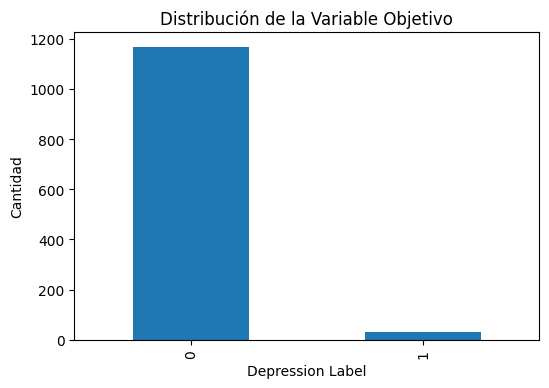

In [75]:
 # TODO EDA - EXPLORATORY DATA ANALYSIS

#! Distribución del target

print("Distribucion depression_label:")
print(df["depression_label"].value_counts())

plt.figure(figsize=(6,4))

df["depression_label"].value_counts().plot(kind="bar")

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Depression Label")
plt.ylabel("Cantidad")

plt.show()

age
13    200
15    180
18    172
17    170
16    163
19    162
14    153
Name: count, dtype: int64


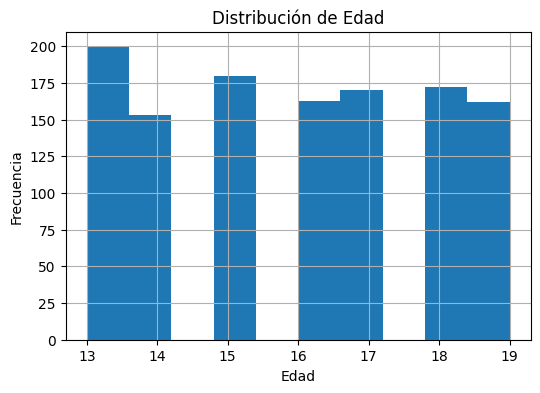

In [76]:
 #! Histograma EDAD

plt.figure(figsize=(6,4))

df["age"].hist()
print(df["age"].value_counts())

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

gender
male      615
female    585
Name: count, dtype: int64


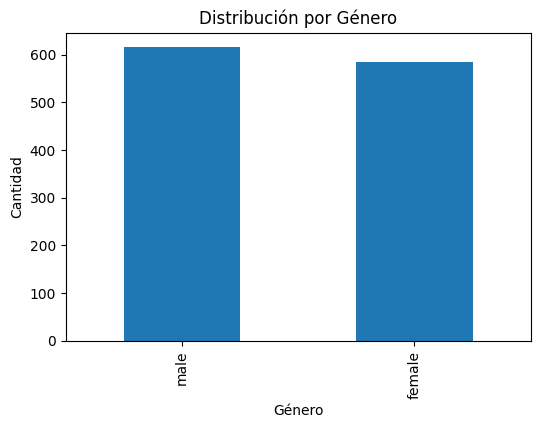

In [77]:
 #! Distribución GENERO

plt.figure(figsize=(6,4))

df["gender"].value_counts().plot(kind="bar")
print(df["gender"].value_counts())

plt.title("Distribución por Género")
plt.xlabel("Género")
plt.ylabel("Cantidad")

plt.show()

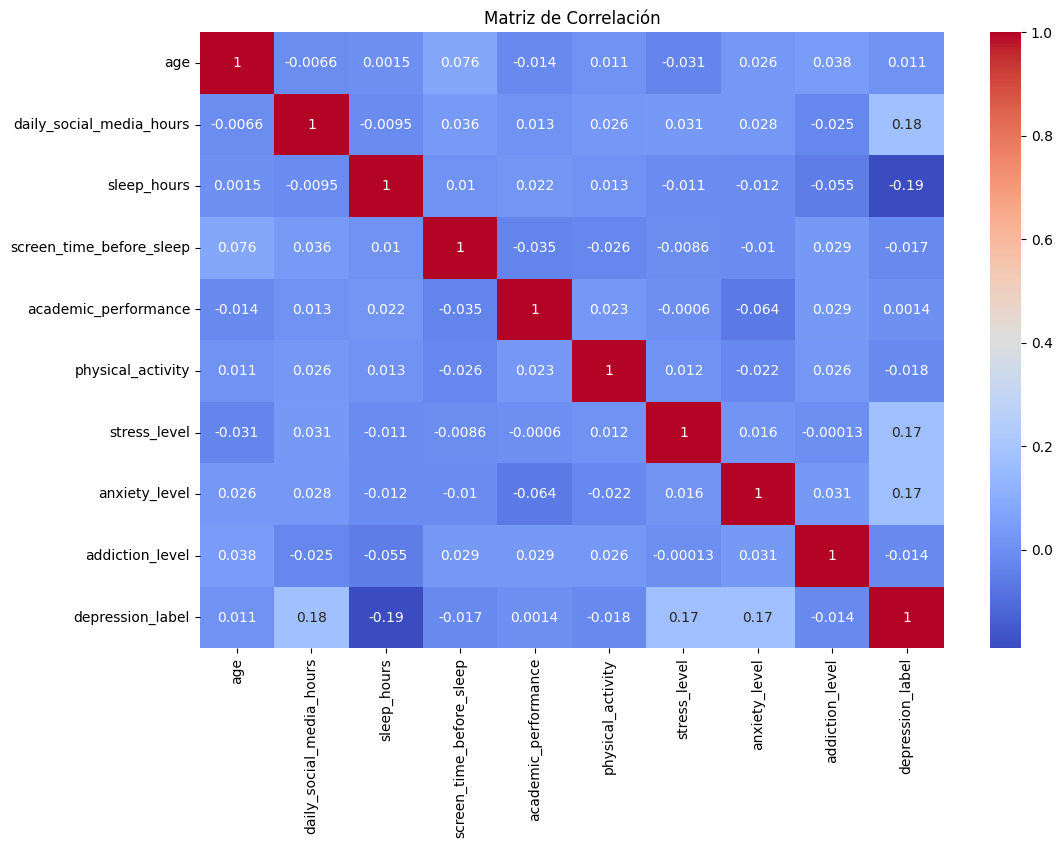

In [78]:
 #! Matriz de correlación

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")

plt.show()

In [79]:
 # TODO: Preprocesamiento

#! Definir X e Y

#* Variable objeto
y = df["depression_label"]

#* Variables predictoras
x = df.drop("depression_label", axis=1)

#! Variables categoricas

print("Columnas antes del encoding:")
print(x.columns)

#* One Hot Encoding

x = pd.get_dummies(x, drop_first=True)

print("\nColumnas después del encoding:")
print(x.columns)

Columnas antes del encoding:
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level'],
      dtype='object')

Columnas después del encoding:
Index(['age', 'daily_social_media_hours', 'sleep_hours',
       'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level', 'addiction_level', 'gender_male',
       'platform_usage_Instagram', 'platform_usage_TikTok',
       'social_interaction_level_low', 'social_interaction_level_medium'],
      dtype='object')


In [80]:
 #! Train / Test

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDatos de entrenamiento:")
print(x_train.shape)

print("\nDatos de prueba:")
print(x_test.shape)

#! Escalamiento

scaler = StandardScaler()

#* Ajustar entrenamiento
x_train_scaled = scaler.fit_transform(x_train)

#* Transformar prueba
x_test_scaled = scaler.transform(x_test)

print("\nEscalamiento realizado correctamente")


Datos de entrenamiento:
(960, 14)

Datos de prueba:
(240, 14)

Escalamiento realizado correctamente


In [81]:
 # TODO: Resultados

print("\nPrimeras filas escaladas:")
print(x_train_scaled[:5])

print("\nPrimeras etiquetas:")
print(y_train.head())


Primeras filas escaladas:
[[ 0.02042178  0.76642066  1.13584497 -0.47654645  0.4763754   1.02962929
   1.56466523 -1.59878278 -0.55321941 -1.01892912  1.39780047 -0.69718585
   1.38169856 -0.73044255]
 [-0.46970086  0.56945537  0.72092443  0.91525333 -0.26816407  0.51302087
   1.56466523  1.56002884 -1.25618517 -1.01892912  1.39780047 -0.69718585
  -0.72374686  1.36903305]
 [-1.44994614 -1.69564544  0.44431074  0.08017347 -0.77029533 -0.34799318
  -0.14185445 -0.1948665   1.55567787  0.98142253 -0.71540969  1.43433777
  -0.72374686 -0.73044255]
 [ 0.02042178  0.37249008 -1.4919851  -0.33736647 -0.78761021 -1.20900722
   0.54075342  0.50709163  1.55567787 -1.01892912 -0.71540969  1.43433777
  -0.72374686 -0.73044255]
 [-0.9598235   0.91414463 -0.31637691 -0.89408638  1.41137844 -0.17579037
   0.88205736 -1.24780371 -0.90470229 -1.01892912  1.39780047 -0.69718585
  -0.72374686  1.36903305]]

Primeras etiquetas:
331    0
409    0
76     0
868    1
138    0
Name: depression_label, dtype: 

# **Implementacion del modelo**

In [82]:
model = LogisticRegression()

In [83]:
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [84]:
y_pred = model.predict(x_test_scaled)

In [85]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9916666666666667


In [86]:
# Precision

precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [87]:
# Recall

recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.6666666666666666


In [88]:
# F1-Score
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.8


[[234   0]
 [  2   4]]


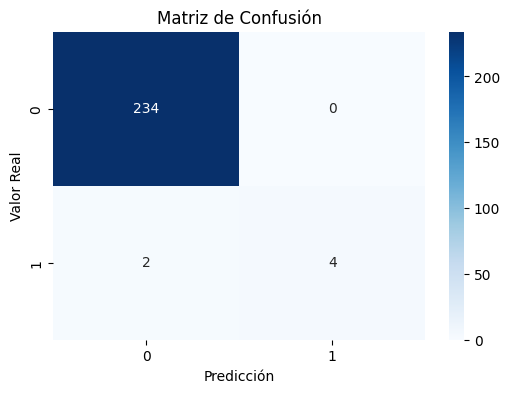

In [91]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [92]:
# Resultados
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240

